# STP Enrolment Credential Preprocessing QA


## Setup and Database Connection
Import required libraries and establish connection to the PSSM databases.

In [4]:
import pandas as pd
import sqlalchemy as sa
import numpy as np
import matplotlib.pyplot as plt

connection_string = "DRIVER={SQL Server};SERVER=decimal.idir.bcgov;DATABASE=PSSM2023"
connection_url = sa.URL.create("mssql+pyodbc", query={"odbc_connect": connection_string})
engine = sa.create_engine(connection_url)

## Enrolment Record Type Summary
This section compares STP Enrolment Record Type distributions between the 2023 and 2025 datasets. Each enrolment record in both model runs is assigned a single Record Status code:

- 0 = Good
- 1 = Missing Student Number
- 2 = Developmental
- 3 = No PSI Transition
- 4 = Credential Only (No Enrolment Record)
- 5 = PSI_Outside_BC
- 6 = Skills Based
- 7 = Developmental CIP
- 8 = Recommendation for Certification 

A full join on RecordStatus, MinEnrolment, and FirstEnrolment compares distributions. Since the 2025 dataset spans two additional years, percentages are compared rather than raw counts to enable fair distributional comparison.

In [2]:
sql23 = sa.text("\
  SELECT [RecordStatus], MinEnrolment, FirstEnrolment, COUNT(*) as n, CAST(ROUND(100.0*COUNT(*)/18761174, 2) AS DECIMAL(5,2)) as p\
  FROM [PSSM2023].[dbo].[STP_Enrolment_Record_Type]\
  GROUP BY RecordStatus, MinEnrolment, FirstEnrolment")
enrol_rec_type_23 = pd.read_sql_query(sql23, con=engine)

sql25 = sa.text("\
  SELECT [RecordStatus], is_min_enrol, is_first_enrol, COUNT(*) as n, CAST(ROUND(100.0*COUNT(*)/18761174, 2) AS DECIMAL(5,2)) as p\
  FROM [PSSM2025].[IDIR\\BASHCROF].[STP_Enrolment_Record_Type_r]\
  GROUP BY RecordStatus, is_min_enrol, is_first_enrol")

enrol_rec_type_25 = pd.read_sql_query(sql25, con=engine)

enrol_rec_type_25 = enrol_rec_type_25.rename(
    columns={"is_min_enrol": "MinEnrolment", "is_first_enrol": "FirstEnrolment"}
)

join_keys = ["RecordStatus", "MinEnrolment", "FirstEnrolment"]

enrol_rec_type_summary = (
    enrol_rec_type_23
    .merge(enrol_rec_type_25, how="outer", on=join_keys, suffixes=(".yr23", ".yr25"))
    .drop(columns=["n.yr23", "n.yr25"])
    .sort_values(join_keys)
    .assign(diff_p=lambda d: d["p.yr23"] - d["p.yr25"])
)
    
enrol_rec_type_summary_styler = (
    enrol_rec_type_summary
    .rename(columns={"p.yr23": "2023(%)", "p.yr25": "2025(%)", "diff_p": "Diff(%)"})
    .style
    .format({"2023(%)": "{:.2f}", "2025(%)": "{:.2f}", "Diff(%)": "{:.2f}"})
    .set_properties(**{'text-align': 'left'}) # Global default for data cells
    .set_properties(subset=["2023(%)", "2025(%)", "Diff(%)"], **{"width": "100px", "text-align": "right"}) # Specific numeric overrides
    .set_properties(subset=["RecordStatus", "MinEnrolment", "FirstEnrolment"], **{"width": "200px"})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
)

enrol_rec_type_summary_styler


,RecordStatus,MinEnrolment,FirstEnrolment,2023(%),2025(%),Diff(%)
0,0,0,0,39.47,43.85,-4.38
1,0,0,1,0.00,nan,nan
2,0,1,0,24.93,27.86,-2.93
3,0,1,1,11.23,12.30,-1.07
4,2,0,0,7.69,8.01,-0.32
5,3,0,0,5.56,5.84,-0.28
6,6,0,0,11.12,12.15,-1.03
7,7,0,0,0.01,0.01,0.00


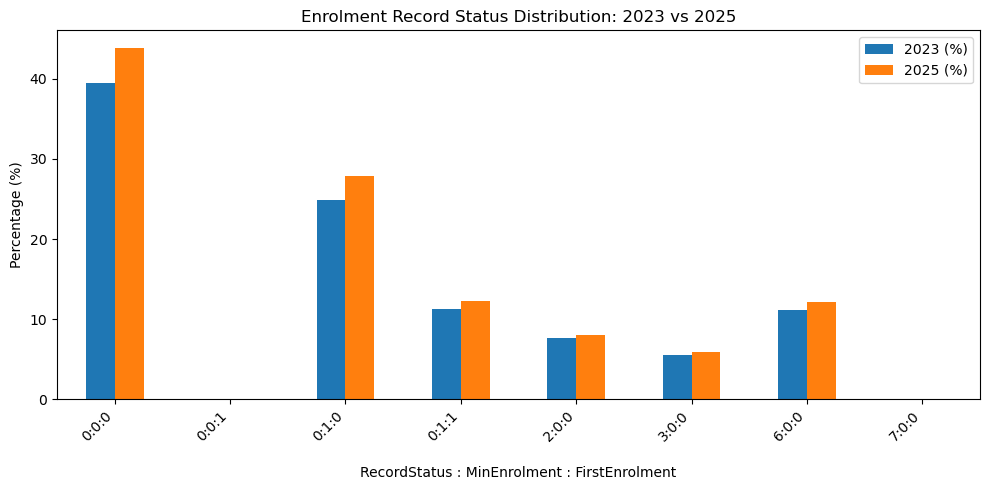

In [3]:
enrol_rec_type_summary["Label"] = (
    enrol_rec_type_summary["RecordStatus"].astype("Int64").astype(str).str.replace("<NA>", "?") + ":" +
    enrol_rec_type_summary["MinEnrolment"].astype("Int64").astype(str).str.replace("<NA>", "?") + ":" +
    enrol_rec_type_summary["FirstEnrolment"].astype("Int64").astype(str).str.replace("<NA>", "?")
)

plot_df = enrol_rec_type_summary.rename(columns={'p.yr23': '2023 (%)', 'p.yr25': '2025 (%)'})

# make the plot
plot_df.plot(
    x='Label', 
    y=['2023 (%)', '2025 (%)'], 
    kind='bar', 
    figsize=(10, 5), 
    title='Enrolment Record Status Distribution: 2023 vs 2025'
)
# tidy aesthetics
plt.ylabel('Percentage (%)')
plt.xlabel('\nRecordStatus : MinEnrolment : FirstEnrolment')
plt.xticks(rotation=45, ha='right') # Rotates labels so they don't overlap
plt.tight_layout()
plt.show()

## Credential Record Type Summary
This section compares STP Credential Record Type distributions between the 2023 and 2025 datasets. In both PSSM model runs, each credential record was assigned a single Record Status code using the same definitions as enrolment records (0 = Good, 1 = Missing Student Number, etc.).

Since the 2025 dataset contains two additional years of data, raw counts differ between cohorts. The code below compares percentages to enable fair distributional comparison.


In [4]:
sql23 = sa.text(
    """
    SELECT [RecordStatus],
           COUNT(*) as n,
           CAST(ROUND(100.0 * COUNT(*) / 18761174, 2) AS DECIMAL(5,2)) as p
    FROM [PSSM2023].[dbo].[STP_Credential_Record_Type]
    GROUP BY [RecordStatus]
    """
)
cred_rec_type_23 = pd.read_sql_query(sql23, con=engine)

sql25 = sa.text(
    """
    SELECT [RecordStatus],
           COUNT(*) as n,
           CAST(ROUND(100.0 * COUNT(*) / 18761174, 2) AS DECIMAL(5,2)) as p
    FROM [PSSM2025].[IDIR\\BASHCROF].[STP_Credential_Record_Type_r]
    GROUP BY [RecordStatus]
    """
)
cred_rec_type_25 = pd.read_sql_query(sql25, con=engine)

cred_rec_type_summary = (
    cred_rec_type_23
    .merge(
        cred_rec_type_25,
        how="outer",
        on="RecordStatus",
        suffixes=(".yr23", ".yr25"),
    )
    .sort_values("RecordStatus")
    .drop(columns=["n.yr23", "n.yr25"])
    .assign(diff_p=lambda d: d["p.yr23"] - d["p.yr25"])
)


cred_rec_type_summary_styler = (
    cred_rec_type_summary
    .rename(columns={"p.yr23": "2023(%)", "p.yr25": "2025(%)", "diff_p": "Diff(%)"})
    .style
    .format({"2023(%)": "{:.2f}", "2025(%)": "{:.2f}", "Diff(%)": "{:.2f}"})
    .set_properties(**{'text-align': 'left'}) # Global default for data cells
    .set_properties(subset=["2023(%)", "2025(%)", "Diff(%)"], **{"width": "100px", "text-align": "right"}) # Specific numeric overrides
    .set_properties(subset=["RecordStatus"], **{"width": "200px"})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
)

cred_rec_type_summary_styler


,RecordStatus,2023(%),2025(%),Diff(%)
0,0,6.96,7.72,-0.76
1,2,0.22,0.23,-0.01
2,6,0.03,0.03,0.00
3,7,0.00,0.00,0.00
4,8,0.06,0.16,-0.10


## Credential Record Type Visualization
Create a bar chart comparing record type distributions between PSSM 2023 and PSSM 2025 cohorts.

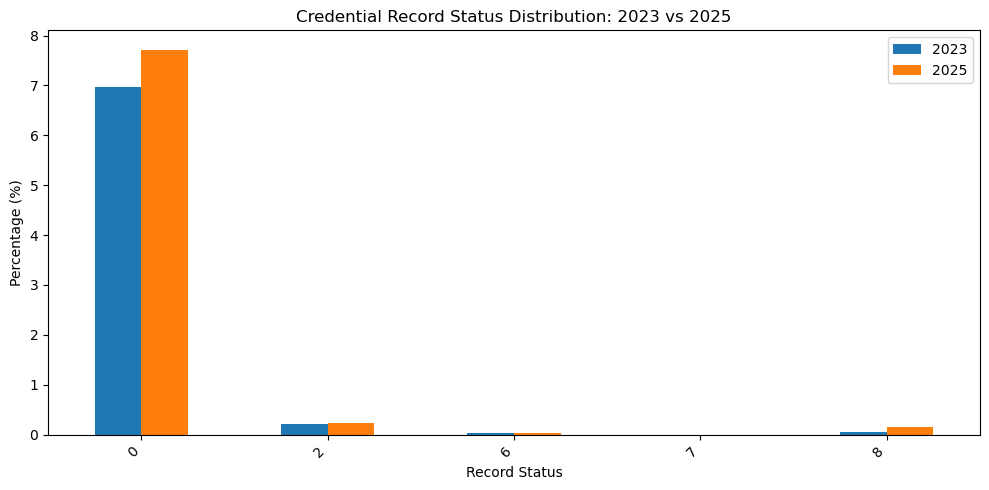

In [5]:
import matplotlib.pyplot as plt

cred_rec_type_summary["Label"] = (
    cred_rec_type_summary["RecordStatus"].astype("Int64").astype(str).str.replace("<NA>", "?")
)

plot_df = cred_rec_type_summary.rename(columns={'p.yr23': '2023 (%)', 'p.yr25': '2025 (%)'})

# make the plot
plot_df.plot(
    x='Label',
    y=['2023 (%)', '2025 (%)'],
    kind='bar',
    figsize=(10, 5),
    title='Credential Record Status Distribution: 2023 vs 2025'
)
plt.ylabel('Percentage (%)')
plt.xlabel('Record Status')
plt.xticks(rotation=45, ha='right') # Rotates labels so they don't overlap
plt.legend(['2023', '2025'])
plt.tight_layout()
plt.show()


## ECDF Plot - Age
An ECDF plot can be used to compare the 2023 and 2025 distributions of psi_birthdate_cleaned because it shows the entire empirical distribution for each age, not just summary stats.

It shows differences in:
- location: one curve would be shifted left/right
- spread: one curve would rise more slowly/quickly
- shape: curve patterns would differ across the range

At each age, x, the ECDF is the proportion of values ≤x.  Formally, for a sample $x_1, ... x_n$: 
$F_n(x) = \frac{1}{n} \sum_{i=1}^{n} I(x_i \le x)$ where $I$ is the indicator function (for $x_i \le x$)

**Age as Reference Point**
Age is computed as of December 31 in the school-year-start year, which allows for consistent age comparison across the 2023 and 2025 cohorts. The full longitudinal span is included to verify that birthdates are imputed consistently across datasets. I *think* this approach is suitable for distribution comparison, but not ideal for more rigorous longitudinal analyses of age spread across enrolments.  

### 1: Data Preparation for Age Distribution Analysis
Query and combine enrolment data with record status = 0 from both cohorts.

In [5]:
sql23 = sa.text(
    """
SELECT
  e.id, 
  e.PSI_SCHOOL_YEAR,
  CAST(e.psi_birthdate_cleaned AS DATE) AS psi_birthdate_cleaned,
  CAST(e.PSI_BIRTHDATE AS DATE) AS PSI_BIRTHDATE,
  CAST(e.LAST_SEEN_BIRTHDATE AS DATE) AS LAST_SEEN_BIRTHDATE
FROM [PSSM2023].[dbo].[STP_Enrolment] AS e
INNER JOIN [PSSM2023].[dbo].[STP_Enrolment_Record_Type] AS rt
  ON e.id = rt.id
WHERE rt.RecordStatus = 0;
    """
)

enrol_birthdates_23 = pd.read_sql_query(sql23, con=engine)
enrol_birthdates_23["source"] = ("2023")

sql25 = sa.text(
    """
    SELECT
      e.id,
      e.PSI_SCHOOL_YEAR,
      CAST(e.psi_birthdate_cleaned AS DATE) AS psi_birthdate_cleaned,
      CAST(e.PSI_BIRTHDATE AS DATE) AS PSI_BIRTHDATE,
      CAST(e.LAST_SEEN_BIRTHDATE AS DATE) AS LAST_SEEN_BIRTHDATE
    FROM [PSSM2025].[IDIR\\BASHCROF].[stp_enrolment_r] AS e
    INNER JOIN [PSSM2025].[IDIR\\BASHCROF].[stp_enrolment_record_type_r] AS rt
      ON e.id = rt.id
    WHERE rt.RecordStatus = 0;
    """
)

enrol_birthdates_25 = pd.read_sql_query(sql25, con=engine)
enrol_birthdates_25["source"] = ("2025")


### 2. Data Transformation
Combine datasets, parse dates, extract school year start, and compute age as of December 31.

In [6]:
# Combine dataframes (2023 and 2025)
cols = [
    "id",
    "PSI_SCHOOL_YEAR",
    "psi_birthdate_cleaned",
    "PSI_BIRTHDATE",
    "LAST_SEEN_BIRTHDATE",
    "source",
]

enrol_birthdates = pd.concat(
    [enrol_birthdates_23[cols], enrol_birthdates_25[cols]],
    ignore_index=True,
    copy=False,
)

# Coerce date columns
date_cols = ["psi_birthdate_cleaned", "LAST_SEEN_BIRTHDATE", "PSI_BIRTHDATE"]
enrol_birthdates[date_cols] = enrol_birthdates[date_cols].apply(
    pd.to_datetime, errors="coerce"
)

# Derive school-year start (first four characters of YYYY/YYYY)
enrol_birthdates["PSI_SCHOOL_YEAR_START"] = pd.to_numeric(
    enrol_birthdates["PSI_SCHOOL_YEAR"].astype("string").str.slice(0, 4),
    errors="coerce",
).astype("Int64")

# Compute age as of December 31 in the school-year-start year.
# This approach checks that birthdates are imputed consistently across years.
year_end = pd.to_datetime(
    enrol_birthdates["PSI_SCHOOL_YEAR_START"].astype("string") + "-12-31",
    errors="coerce",
)

enrol_birthdates["age"] = (year_end - enrol_birthdates["psi_birthdate_cleaned"]).dt.days.div(365.2425)

enrol_birthdates.head(5)

,id,PSI_SCHOOL_YEAR,psi_birthdate_cleaned,PSI_BIRTHDATE,LAST_SEEN_BIRTHDATE,source,PSI_SCHOOL_YEAR_START,age
0,2,2021/2022,2002-12-30,2002-12-30,2002-12-30,2023,2021,19.003813
1,3,2021/2022,2002-12-30,2002-12-30,2002-12-30,2023,2021,19.003813
2,4,2021/2022,2002-07-14,2002-07-14,2002-07-14,2023,2021,19.466519
3,5,2021/2022,2002-07-14,2002-07-14,2002-07-14,2023,2021,19.466519
4,6,2021/2022,2002-09-30,2002-09-30,2002-09-30,2023,2021,19.252962


## Data Filtering
Applies the following validity filters to prepare data for ECDF comparison:

1. Remove rows where psi_birthdate_cleaned == 1900-01-01 (placeholder/missing dates).
2. Keep only ages in the range [0, 100] to exclude implausible values.
3. Ensure fair comparison by restricting each dataset to a 10-year lookback:
    - 2023 cohort: school years starting 2014 or later (2014–2023)
    - 2025 cohort: school years starting 2016 or later (2016–2025)

In [7]:

# Some filtering and transforming
birthdate_is_valid = enrol_birthdates["psi_birthdate_cleaned"].ne(pd.Timestamp("1900-01-01"))
age_is_valid = enrol_birthdates["age"].between(0, 100)

# include only a 10-year window
cohort_window = (
    ((enrol_birthdates["source"] == "2023") & (enrol_birthdates["PSI_SCHOOL_YEAR_START"] >= 2014))
    | ((enrol_birthdates["source"] == "2025") & (enrol_birthdates["PSI_SCHOOL_YEAR_START"] >= 2016))
)

# Make plot data
birthdate_ecdf_plot_data = (
    enrol_birthdates.loc[birthdate_is_valid & age_is_valid & cohort_window, ["source", "age"]]
    .dropna(subset=["age"])
    .copy()
)

birthdate_ecdf_plot_data.head(5)

,source,age
0,2023,19.003813
1,2023,19.003813
2,2023,19.466519
3,2023,19.466519
4,2023,19.252962


## ECDF Plot Visualization
Plot empirical cumulative distribution functions for age comparison (yellow for 2023, blue for 2025; green where overlapping).

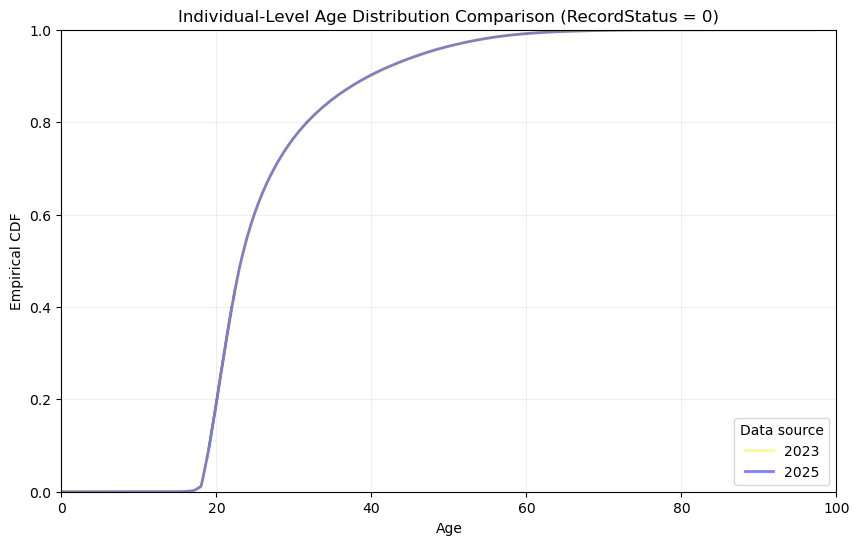

In [9]:

fig, ax = plt.subplots(figsize=(10, 6))

source_order = ["2023", "2025"]
source_colors = {"2023": "yellow", "2025": "blue"}

# Make matplotlib plot data
for source in source_order:
    s = birthdate_ecdf_plot_data.loc[
        birthdate_ecdf_plot_data["source"] == source, "age"
    ].dropna()

   # Aggregate first: one point per unique age value
    counts = s.value_counts().sort_index()
    x = counts.index.to_numpy()
    y = counts.cumsum().to_numpy() / counts.sum()

    ax.step(x, y, where="post", linewidth=2, alpha=0.5, color=source_colors[source], label=source)

# formatting options
ax.set_title("Individual-Level Age Distribution Comparison (RecordStatus = 0)")
ax.set_xlabel("Age")
ax.set_ylabel("Empirical CDF")
ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
ax.legend(title="Data source", loc="lower right")
ax.grid(alpha=0.2)

## Check Age Distribution Equivalence (Two-Sample Kolmogorov–Smirnov Test)

To assess whether psi_birthdate_cleaned behaves consistently across cohorts, this section compares the end-of-year age distributions for enrolment records from the prior 10 years in the 2023 and 2025 cohorts. A two-sample Kolmogorov–Smirnov (KS) test is used because it is a nonparametric method that compares entire empirical cumulative distribution functions (ECDFs), making it sensitive to differences in both distribution location and shape.

The hypotheses are:
​
- H0: the 2023 and 2025 samples are drawn from the same age distribution
- H1: the two samples are drawn from different age distributions

If H0 is not rejected, that supports the claim that psi_birthdate_cleaned has comparable distributions across cohorts. If H0 is rejected, it indicates a detectable distributional difference between cohorts.

The Kolmogorov–Smirnov statistic for a given cumulative distribution function $F(x)$ is:

$$D = sup_x |F1(x) - F2(x)|$$

Where $F1(x)$, $F2(x)$ are the empirical cumulative distribution functions for the 2023 and 2025 cohorts, respectively.  $sup_x$ is the supremum (similar to maximum) of the set of distances => $D$ takes the largest absolute difference between the two distribution functions across all $x$ values.  

$D$ is a measure of the similarity of the two age distributions; small $D$ (close to 0) indicates similar distributions, while large $D$ indicates greater differences.


In [10]:

from scipy.stats import ks_2samp


age_2023 = birthdate_ecdf_plot_data.loc[lambda d: d["source"] == "2023", "age"].to_numpy()
age_2025 = birthdate_ecdf_plot_data.loc[lambda d: d["source"] == "2025", "age"].to_numpy()
ks_result = ks_2samp(age_2023, age_2025, alternative="two-sided", method="asymp")

pd.DataFrame(
    {
        "n_2023": [age_2023.size],
        "n_2025": [age_2025.size],
        "ks_statistic": [ks_result.statistic],
        "p_value": [ks_result.pvalue],
        "stat_location": [ks_result.statistic_location],
        "stat_sign": [ks_result.statistic_sign],
    }
)

,n_2023,n_2025,ks_statistic,p_value,stat_location,stat_sign
0,6595413,6775860,0.005448,1.350808e-86,22.360487,-1
